## Exercise Project 1 -- Linear Regression
### Dataset: [NYC Housing Prices](https://www.kaggle.com/datasets/ishank2005/nyc-housing-prices-csv)


<br>

<br>

##### Shape: `34k rows, 19 columns`

##### Target Variable: `sale_price`

##### Method: `Linear Regression`

##### Extra Tools: `Mlflow`

##### Column Descriptions (Complete):

| Column        | Description |
|--------------|-------------|
| borough_x    | *Borough code associated with the property sale record, sourced from the NYC Citywide Rolling Sales dataset.* |
| block        | *NYC tax block identifier for the property, used as part of the Borough–Block–Lot (BBL) system.* |
| lot          | *NYC tax lot identifier for the property, used as part of the Borough–Block–Lot (BBL) system.* |
| sale_price   | *Recorded sale price of the property transaction in US dollars. Non-arm’s-length and invalid transactions have been removed.* |
| zip_code     | *ZIP code of the property as recorded in the sales transaction data.* |
| borough_y    | *Borough code associated with the property tax lot, sourced from the PLUTO building dataset.* |
| yearbuilt    | *Year in which the primary structure on the tax lot was originally constructed.* |
| lotarea      | *Total land area of the tax lot, measured in square feet.* |
| bldgarea     | *Total gross building floor area on the tax lot, measured in square feet.* |
| resarea      | *Portion of the building floor area used for residential purposes, measured in square feet.* |
| comarea      | *Total commercial floor area within the building, measured in square feet.* |
| unitsres     | *Number of residential housing units on the tax lot.* |
| unitstotal   | *Total number of units on the tax lot, including residential and non-residential units.* |
| numfloors    | *Number of floors in the primary building on the tax lot.* |
| latitude     | *Latitude coordinate of the property location, expressed in decimal degrees.* |
| longitude    | *Longitude coordinate of the property location, expressed in decimal degrees.* |
| landuse      | *Numeric land use category code describing the primary use of the property (e.g., residential, commercial, mixed-use).* |
| bldgclass    | *NYC building class code indicating the structural and usage classification of the property.* |
| building_age | *Age of the building in years at the time of sale, calculated as sale year minus year built.* |


<br>
<br>

<i> 

This is the main notebook for exercise project 1. The approach for this notebook was to have only minimal comments and readability (my initial version had way too much explanations).

This project is NOT a house-price dataset, but a lot-price dataset. 
There dataset is complex and has quite a few problems; Notably, really small correlation values and lots of missing information. 
If you're curious about the missing information aspect of this, I mention it later in my personal analysis at the end. 


---

### Code

In [463]:
# import 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.preprocessing import OneHotEncoder
import joblib

# Reading the dataframe and storing it.
df = pd.read_csv("datasets/nyc_housing.csv")
df.head(5)

,borough_x,block,lot,sale_price,zip_code,borough_y,yearbuilt,lotarea,bldgarea,resarea,comarea,unitsres,unitstotal,numfloors,latitude,longitude,landuse,bldgclass,building_age
0,1,400,11,280000,10009.0,MN,1900.0,2404.0,6875.0,6875.0,0.0,18.0,18.0,5.0,40.724415,-73.983891,2.0,C6,125.0
1,1,402,36,2000000,10009.0,MN,1900.0,1919.0,7810.0,6810.0,1000.0,8.0,10.0,5.0,40.724975,-73.981535,2.0,C4,125.0
2,1,402,60,3400000,10009.0,MN,1920.0,2150.0,6152.0,5352.0,800.0,8.0,9.0,5.0,40.725346,-73.983112,4.0,C7,105.0
3,1,404,42,4000000,10009.0,MN,1855.0,2369.0,6990.0,6990.0,0.0,10.0,10.0,5.0,40.727398,-73.980600,2.0,C4,170.0
4,1,372,55,655000,10009.0,MN,1920.0,5298.0,17990.0,17990.0,0.0,20.0,20.0,5.0,40.720621,-73.979534,2.0,C6,105.0


## Cleaning

|Step|Description|
|---|---|
|1|<bold style="background:yellow;color:black;"> Data Cleaning </bold>|
|2| Transformation|
|3| ML Training & Metrics|
|4|Tester Row Values|
|5| Personal Analysis |
|6| Advanced Tasks|

#### Checking The Dataframe Shape

In [464]:
# Checking the amount of columns and rows.
df.shape


(34439, 19)

#### Handling Missing Values

In [465]:
# Checking for missing values
df.isna().sum()

# A small amount of rows have missing values. 
# Getting rid of all the NaN will be trivial 200/34000 = .5% of the data. Not timeseries, so it's fine.

borough_x         0
block             0
lot               0
sale_price        0
zip_code         16
borough_y         0
yearbuilt         0
lotarea           0
bldgarea          0
resarea         188
comarea         188
unitsres          0
unitstotal        0
numfloors        43
latitude          6
longitude         6
landuse           3
bldgclass         0
building_age      0
dtype: int64

In [466]:
# Dropping nan values.
df = df.dropna()

#### Handling Duplicates

In [467]:
# Checking for duplicates
df.duplicated().value_counts()

# Some duplicates do exist. We can safely get rid of these.

False    33204
True       999
Name: count, dtype: int64

In [468]:
# Dropping the duplicate rows.
df = df.drop_duplicates()

#### Dropping Columns

Here, we'll be dropping some of the columns which we know we won't be using.




In [469]:
# Dropping co-dependent/high collinearity columns
df = df.drop(["borough_x",       # Related to borough_y
                'latitude',      # Probably just noise in the data.
                'longitude',     # Probably just noise in the data.
                'yearbuilt',     # This is co-dependent with `buildingage`
                'comarea',       # In this dataset: bldgarea = comarea + resarea. co-dependent.
                'resarea',       # In this dataset: bldgarea = comarea + resarea. co-dependent.
                'lot',           # We have borough_y. This is too specific, you'd have distributions of 1 unit being in lot ABC, hardly statistical.
                'block',         # We have borough_y, too specific. We cant have 3 units in a block be a statistical weight for an ML model.
                'zip_code',      # Too specific, it'll affect distribution.
                'landuse',       # This is often co-dependent with bldgclass (D4 bldgclass = landuse 3 for example).      
], axis=1)

# `borough_y` and `bldglclass` is categorical, we'll convert this to numbers. 
df.head(3)


,sale_price,borough_y,lotarea,bldgarea,unitsres,unitstotal,numfloors,bldgclass,building_age
0,280000,MN,2404.0,6875.0,18.0,18.0,5.0,C6,125.0
1,2000000,MN,1919.0,7810.0,8.0,10.0,5.0,C4,125.0
2,3400000,MN,2150.0,6152.0,8.0,9.0,5.0,C7,105.0


#### Categorical Feature Isolated Case Elimination

##### `bldgclass`

In [470]:
# In `bldgclass`, there are isolated cases there just isn't enough data
# to give a fair statistical weight to them.
value_counts = df['bldgclass'].value_counts().sort_values(ascending=True)
value_counts

# This eliminates any building classes that have less than 20 values. 
df = df[df['bldgclass'].isin(value_counts[value_counts >= 20].index)]

#### Categorical Feature Isolated Case Elimination

##### `borough_y`

In [471]:
# Let's check the other categorical feature, `borough_y`
df['borough_y'].value_counts()

# This seems ok! plenty of data to work with.

borough_y
QN    12619
BK     9532
SI     3842
MN     3717
BX     3221
Name: count, dtype: int64

#### Turning Categorical Columns into Numbers

In [472]:
# List of columns to convert to numbers.
categorical_columns = ["borough_y",  # Example values: MN, ME, BK
                       "bldgclass",  # Example values: C6, K4, C8
                       ]


# Converts columns into binary, separate columns.
for column in categorical_columns:
    encoder = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
    one_hot_encoded = encoder.fit_transform(df[[column]]).astype(int)
    df = pd.concat([df.drop(columns=[column]), one_hot_encoded], axis=1)


df.head(3)

,sale_price,lotarea,bldgarea,unitsres,unitstotal,numfloors,building_age,borough_y_BK,borough_y_BX,borough_y_MN,...,bldgclass_O2,bldgclass_O5,bldgclass_O7,bldgclass_O8,bldgclass_S1,bldgclass_S2,bldgclass_S3,bldgclass_S4,bldgclass_S5,bldgclass_S9
0,280000,2404.0,6875.0,18.0,18.0,5.0,125.0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,2000000,1919.0,7810.0,8.0,10.0,5.0,125.0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,3400000,2150.0,6152.0,8.0,9.0,5.0,105.0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


---



### Transformation

|Step|Description|
|---|---|
|1| Data Cleaning|
|2| <bold style="background:yellow;color:black;">Transformation </bold>|
|3| ML Training & Metrics|
|4|Tester Row Values|
|5| Personal Analysis |
|6| Advanced Tasks|



####  Target Outlier & Skew Elimination

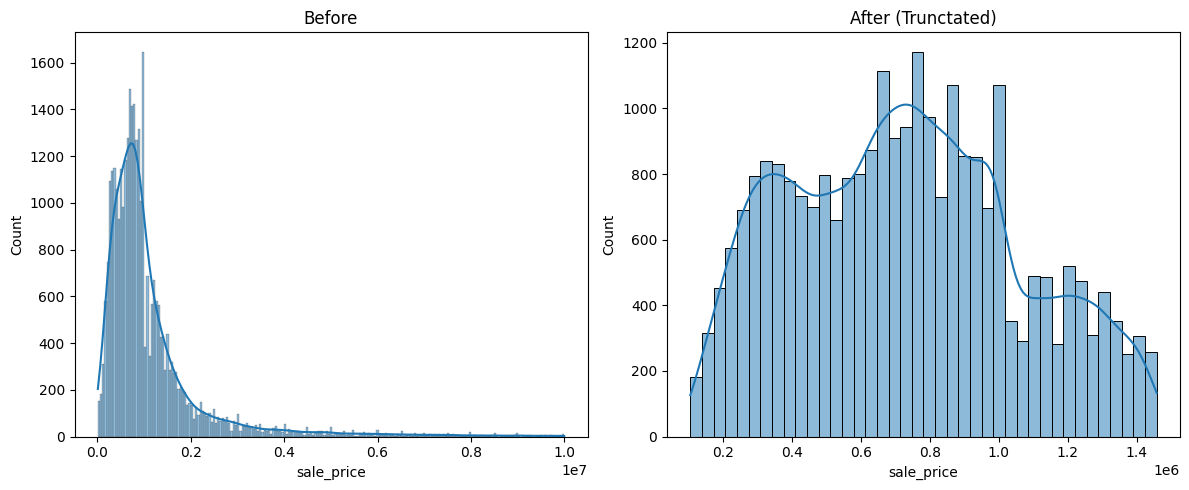

Rows left: 26016


In [473]:
from sklearn.preprocessing import PowerTransformer

# Target variable cutoffs (these constants show up in MLFLOW to track parameters of the run).
y_trunc_floor = 0.01
y_trunc_ceiling = 0.80

# Creates three canvases for histplots to show my work.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))


# Histplot 0
sns.histplot(df, x='sale_price', ax=axes[0], kde=True)

# Truncating the Y variable.
df = df[
    (df["sale_price"] >= df["sale_price"].quantile(q=y_trunc_floor)) &
    (df["sale_price"] <= df["sale_price"].quantile(q=y_trunc_ceiling))
    ]

# Histplot 1
sns.histplot(df, x='sale_price', ax=axes[1], kde=True)




# Plot titles
axes[0].set_title("Before")
axes[1].set_title("After (Trunctated)")
plt.tight_layout()
plt.show()


# SANITY CHECK:
# Let's check how many rows we have left.
print(f"Rows left: {df.shape[0]}")

#### Checking Feature Distributions

I could have ran all this using a loop, I decided to do it 'feature-by-feature`. That way I can show my work.

`unitsres`

Text(0.5, 1.0, 'Yeojohnson')

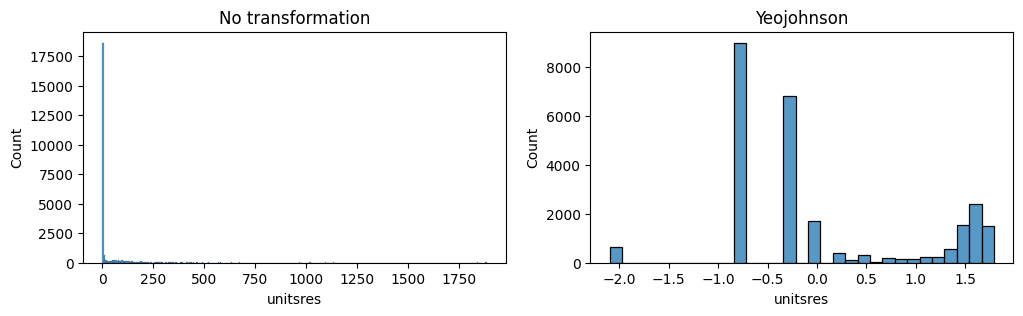

In [474]:
# Creates three canvases for histplots to show my work.
fig, axes = plt.subplots(1, 2, figsize=(12, 3))

# Histplot 1 
sns.histplot(df, x="unitsres", ax=axes[0])

# Fixing the feature distribution by truncation.
pt = PowerTransformer(method='yeo-johnson')
df['unitsres'] = pt.fit_transform(df[['unitsres']])

# Histplot2
sns.histplot(df, x="unitsres", ax=axes[1])

# Titles
axes[0].set_title("No transformation")
axes[1].set_title("Yeojohnson")

# Huh, bimodal distribution. Interesting result. 
# Lots of lots that only have one total unit inside. Some even have none.

# I'm not an expert, but this probably means that these two distributions would create noise.

Text(0.5, 1.0, 'Higher Cluster (from the bimodal dist)')

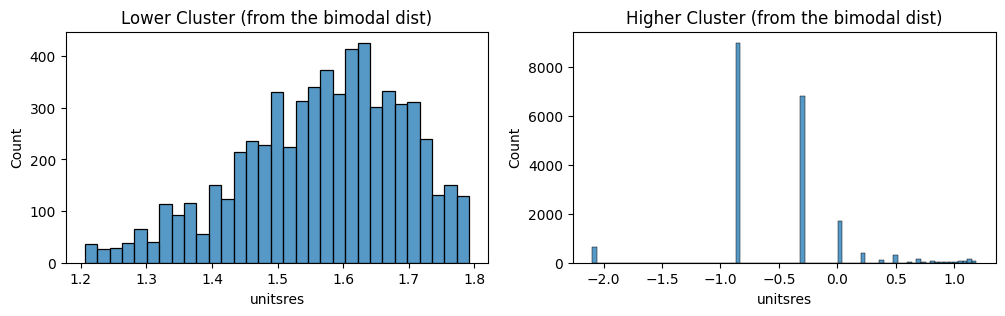

In [475]:
# We create binary columns so the model accounts for these two distributions somewhat.
df["is_high_cluster_unitsres"] = (df["unitsres"] > 1.2).astype(int)

# If it's less than three, 1 -- else, 0.
df['is_high_cluster_unitsres'].value_counts()

# I'll show you what I'm doing here.

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 3))

# Make two filters, we'll look at the distribution of each.
filter1 = df[df["is_high_cluster_unitsres"] == 1]
filter2 = df[df["is_high_cluster_unitsres"] == 0]

# Create histplots
sns.histplot(filter1, x="unitsres", ax=axes[0])
sns.histplot(filter2, x="unitsres", ax=axes[1])

# Set titles
axes[0].set_title("Lower Cluster (from the bimodal dist)")
axes[1].set_title("Higher Cluster (from the bimodal dist)")

#
# By creating a binary feature that divides the two distributions in that bi-modal distribution,
# We let the model create a weight system that helps offset some of the infighting these two
# distributions in the feature have.

# If, it's in the higher cluster, give is a 1
# Else, give it a 0

`lotarea`

Text(0.5, 1.0, 'Log transformation')

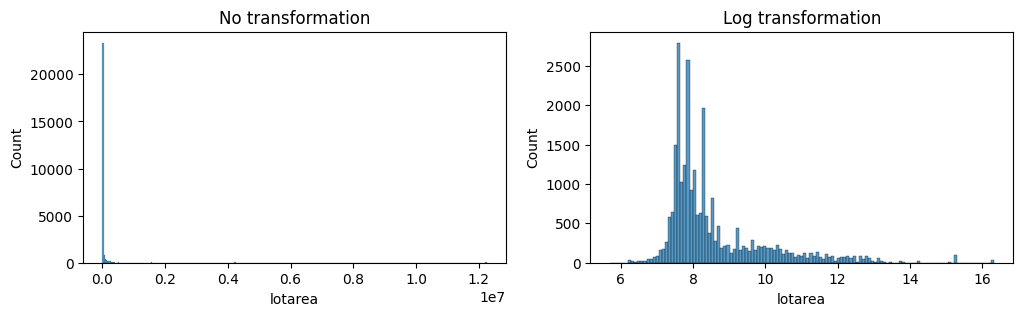

In [476]:
# Create a new canvas for subplots
fig, axes = plt.subplots(1, 2, figsize=(12,3))

# Histplot 1 (no changes)
sns.histplot(df, x='lotarea', ax=axes[0])

# Use log transformation to normalize
df['lotarea'] = np.log1p(df[['lotarea']])

# Histplot 2 (Log transformation)
sns.histplot(df, x='lotarea', ax=axes[1])

# Titles
axes[0].set_title("No transformation")
axes[1].set_title("Log transformation")



`unitstotal`

Text(0.5, 1.0, 'Yeojohnson')

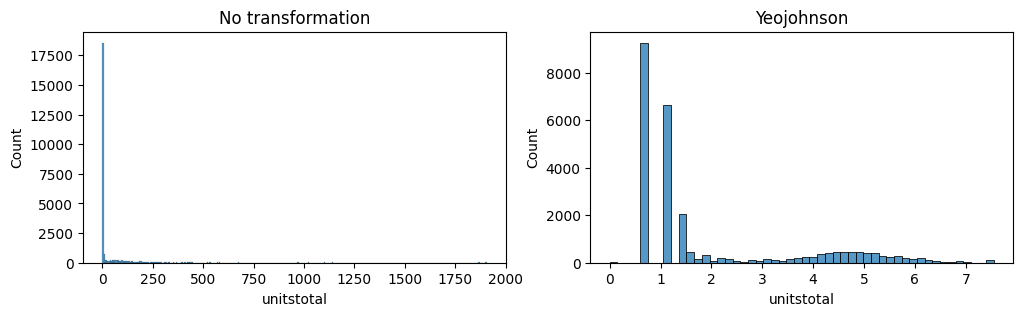

In [477]:
fig, axes = plt.subplots(1, 2, figsize=(12,3))

# Histplot 1 (no changes)
sns.histplot(df, x='unitstotal', ax=axes[0])


# # Root transformation
df['unitstotal'] = np.log1p(df[['unitstotal']])

# Histplot 2 (Log Transformation)
sns.histplot(df, x='unitstotal', ax=axes[1])

# Titles
axes[0].set_title("No transformation")
axes[1].set_title("Yeojohnson")


In [478]:
#  We create binary columns so the model accounts for these two distributions somewhat.
df["is_high_cluster_unitstotal"] = (df["unitstotal"] > 3).astype(int)

# If it's less than three, 1 -- else, 0.
df['is_high_cluster_unitstotal'].value_counts()

# df['is_high_cluster_unitstotal'].value_counts()

is_high_cluster_unitstotal
0    19546
1     6470
Name: count, dtype: int64

`bldgarea`

Text(0.5, 1.0, 'Yeojohnson')

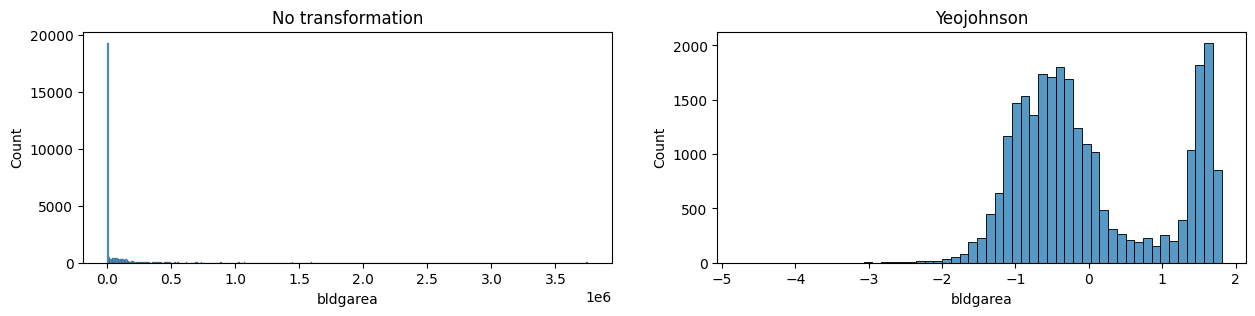

In [479]:
fig, axes = plt.subplots(1, 2, figsize=(15,3))

# Histplot 1 (no changes) 
sns.histplot(df, x='bldgarea', ax=axes[0])

# Fixing the feature distribution by truncation.
df['bldgarea'] = pt.fit_transform(df[['bldgarea']])

# Histplot 2 (Yeojohnson Transformation) 
sns.histplot(df, x='bldgarea', ax=axes[1])

# Titles
axes[0].set_title("No transformation")
axes[1].set_title("Yeojohnson")

# Same thing, bimodal distribution.

In [480]:
#  We create binary columns so the model accounts for these two distributions somewhat.
df["is_high_cluster_bldgarea"] = (df["bldgarea"] > 1).astype(int)

# If it's less than three, 1 -- else, 0.
df['is_high_cluster_bldgarea'].value_counts()

# df['is_high_cluster_unitstotal'].value_counts()


is_high_cluster_bldgarea
0    19472
1     6544
Name: count, dtype: int64

`building_age`

<Axes: xlabel='building_age', ylabel='Count'>

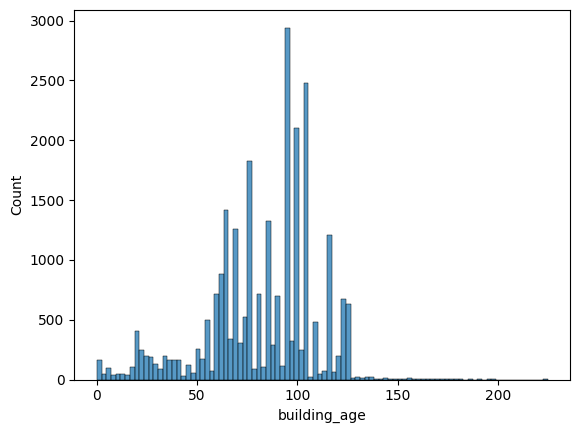

In [481]:
# Checking the distribution of `building_age`
sns.histplot(df, x='building_age')

# Seems ok!

---

### Selecting Features

#### Pearson Correlation


In [482]:
# Find the most correlated values. (using absolute value)
correlations = df.corr( method='pearson',numeric_only=True).sort_values(by='sale_price')
correlations = abs(correlations["sale_price"])

corr_df = pd.DataFrame(correlations).reset_index()

# Renaming the columns to make it tidy.
corr_df = corr_df.rename(columns={
    "index": "Feature",
    "sale_price": "Absolute Correlation Value"
})

# Filtering out `sale_price`
corr_df = corr_df[corr_df["Feature"] != "sale_price"]
corr_df = corr_df[corr_df["Feature"] != "sale_price"]
corr_df

,Feature,Absolute Correlation Value
0,is_high_cluster_unitstotal,0.416244
1,is_high_cluster_bldgarea,0.411401
2,is_high_cluster_unitsres,0.410456
3,unitstotal,0.384949
4,lotarea,0.368103
...,...,...
62,bldgclass_A1,0.071247
63,bldgclass_B3,0.099258
64,bldgclass_C0,0.108361
65,bldgclass_B1,0.117643


#### Narrowing down feature candidates

In [483]:
# Let's intially narrow down some options. 
features_list = list(corr_df["Feature"].head(15))
features_list

# NOTE:
# This list is going to be which features we'll be using for our model. We'll narrow it down as we go.

['is_high_cluster_unitstotal',
 'is_high_cluster_bldgarea',
 'is_high_cluster_unitsres',
 'unitstotal',
 'lotarea',
 'bldgclass_D4',
 'unitsres',
 'bldgarea',
 'bldgclass_C6',
 'numfloors',
 'bldgclass_G4',
 'borough_y_BX',
 'borough_y_MN',
 'bldgclass_D1',
 'bldgclass_D3']

### Fisher Score

<Axes: >

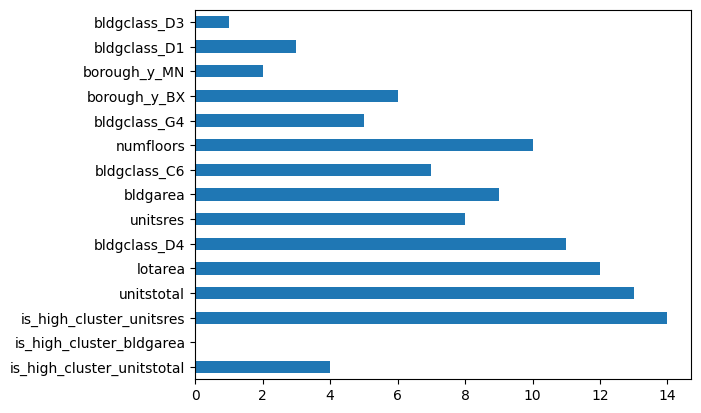

In [484]:
sample = df.sample(2000)

X = sample[features_list]
y = sample['sale_price']

# pip install skfeature-chappers
from skfeature.function.similarity_based import fisher_score

# get the fisher's score rankings 
ranks = fisher_score.fisher_score(X.values, y.values)

# create a pandas DataFrame for easier interpretation
feat_importances = pd.Series(ranks, X.columns)
feat_importances.plot(kind='barh')

# Fisher's score studies the variance of the data -> statistical significance

<Axes: xlabel='Features', ylabel='Score'>

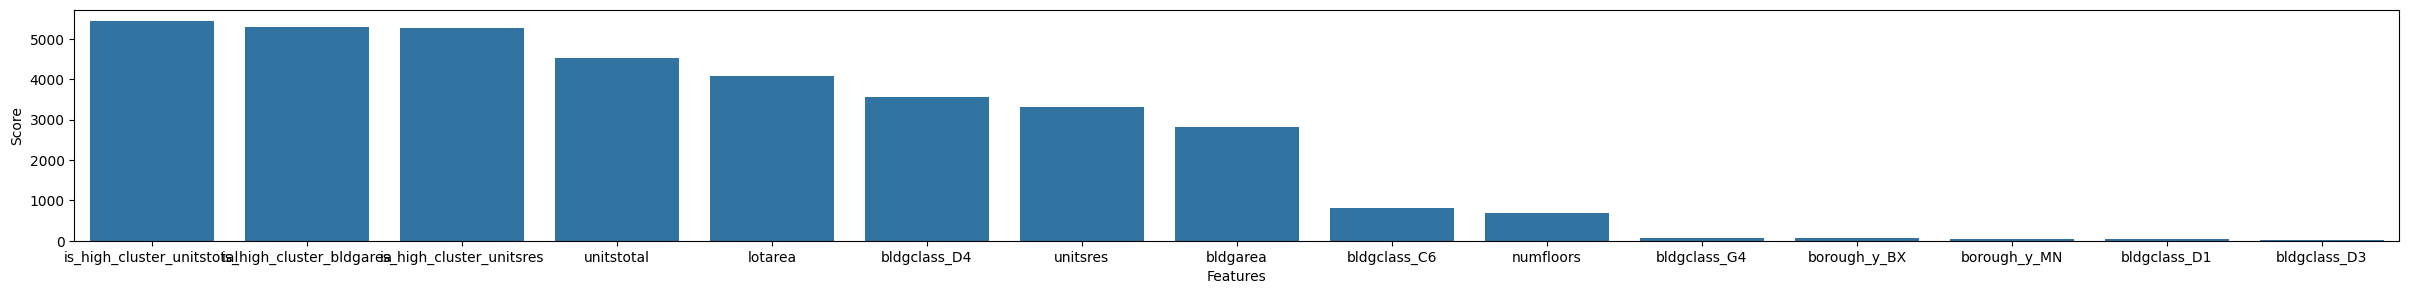

In [485]:
# -- SELECTKBEST --
# Basically, rank the features by statistical significance.
# Works with regression or classification

from sklearn.feature_selection import SelectKBest, f_regression

X = df[features_list]
y = df['sale_price']

# convert all continuous variables to integer
X_cat = X.astype(int) 


# Use chi squared to help provide provide statistical
# significance metrix.
chi_2_features = SelectKBest(f_regression, k=10)

# fit our data to the SelectKBest
best_features = chi_2_features.fit(X, y)

# Turn the features and columns into dataframes.
df_features = pd.DataFrame(best_features.scores_)
df_columns = pd.DataFrame(X.columns)

# Combine them and sort the values by 'Score'
f_scores = pd.concat([df_columns,df_features],axis=1)
f_scores.columns = ['Features','Score']
f_scores.sort_values(by='Score',ascending=False)

# Showing the scores
plt.figure(figsize=(30,3))
sns.barplot(f_scores, x="Features", y='Score')

In [486]:
# Remove these features. It's noise. We're not training the model with this.
features_list.remove("bldgclass_G4")
features_list.remove("bldgclass_D3")
features_list.remove("bldgclass_D1")
features_list.remove("borough_y_BX")
features_list.remove("borough_y_MN")

#### Checking for Feature Independence (via Correlation Heatmap)

Our last step for selecting these features is to be sure that these features are independent from one-another. We're going to do this via using a correlation heatmap. We'll only be looking at `X`, meaning the feature candidates that we could be using to predict the target variable `Y`.

<Axes: >

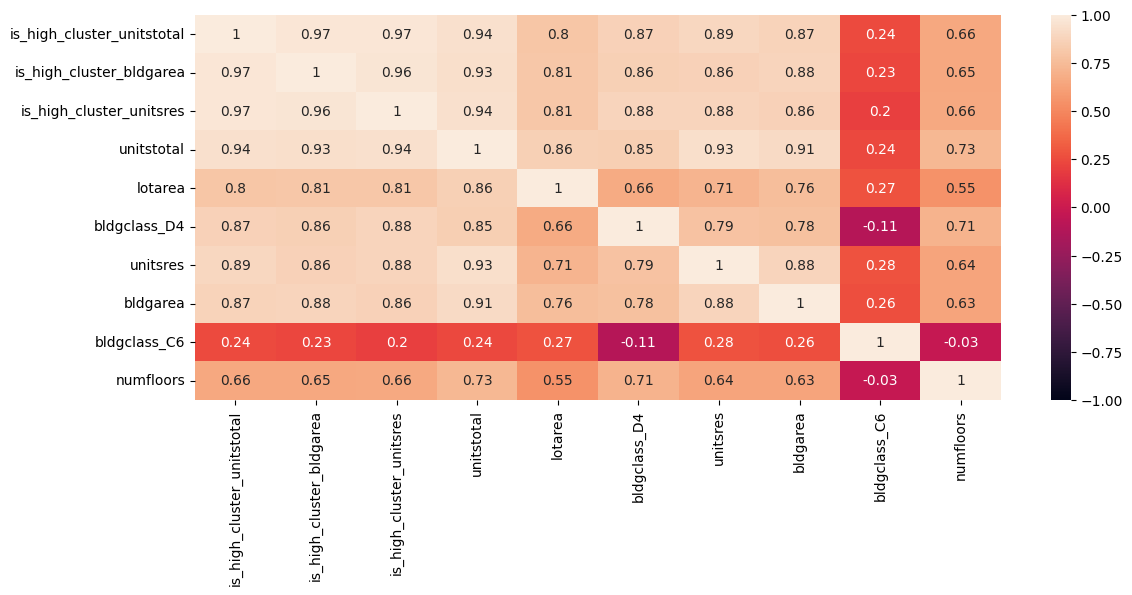

In [487]:
# Create a list correlation heatmap of all the feature candidates.
correlation = df[features_list].corr(numeric_only=True)
plt.figure(figsize=(13,5))
sns.heatmap(correlation, annot=True, vmin=-1, vmax=1)


#### 

In [488]:
# I've tried getting rid of multicollinearity, but it made the model worse.

# features_list.remove("unitsres")
# features_list.remove("bldgarea")
# features_list.remove("is_high_cluster_unitstotal")
# features_list.remove("is_high_cluster_bldgarea")
# features_list

# It's probably because they're not COMPLETELY redundant. They're multicollinear. But not significantly enough not to be valuable.

---

### ML Implementation

|Step|Description|
|---|---|
|1| Data Cleaning |
|2| Transformation|
|3|<bold style="background:yellow;color:black;">ML Training & Metrics</bold>|
|4| Tester Row Values|
|5| Personal Analysis|
|6| Advanced Tasks|


#### `LinearRegression` ML Model Training & Logging

If you've been paying attention, you may have noticed us using constants a lot. That's for `mlflow` an MLOPS tool.
In this case, I'll be using it to log and track parameters so I know what optimization changes have been working with this dataset.

If you're curious:

|step|instructions|
|---|---|
|1| Run the cell below|
|2| Type `mlflow ui` in the venv's command prompt and open your browser to http://localhost:5000/.|
|3| You can see the parameters and metrics for each run performed locally in the `ex1_project_a` mlruns section.|

Otherwise, feel free to skip all this. It runs just like normal.








In [489]:

# Constants (These are used to log the parameters in mlflow, that way I can remember what works)
XY_SPLIT = 0.3

# Defining dependent, independent variables.
X = df[features_list]
y = df['sale_price']

# train/test-split.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=XY_SPLIT, random_state=101)

# Initalize and fit the model.
lm = LinearRegression()
lm.fit(X_train, y_train)

# Find the intercept value of the regression.
intercept = lm.intercept_

# Create a list of coefficients for each feature.
coefs = lm.coef_
print(coefs)

# Predict the data with the model.
predictions = lm.predict(X_test)

# Metrics recording (print is in the cell below)
mae = metrics.mean_absolute_error(y_test, predictions)
mse = metrics.mean_squared_error(y_test, predictions)
rmse = np.sqrt(metrics.mean_squared_error(y_test, predictions))
r_sq = metrics.r2_score(y_test, predictions)

# Save the model using joblib
joblib.dump(lm, "models/ex1_main.pkl")


[-149694.68509753  -96936.07445842     640.44369317 -123979.01654182
    9808.03525789 -184592.54823236   95824.97974578  103980.32393386
 -210481.81825807   18519.11415678]


['models/ex1_main.pkl']

#### Metric & Parameter Prints

In [490]:
# -- METRICS RECORDING -- 
mae = metrics.mean_absolute_error(y_test, predictions)
mse = metrics.mean_squared_error(y_test, predictions)
rmse = np.sqrt(metrics.mean_squared_error(y_test, predictions))
r_sq = metrics.r2_score(y_test, predictions)


# -- PRINT METRICS --
print("METRICS")
print("--------------------------")
print("MAE")
print(f"{round(mae,2)} \n")
print("MSE")
print(f"{round(mse,2)} \n")
print("RMSE")
print(f"{round(rmse,2)} \n")
print('R-squared:')
print(f"{round(r_sq,2)} \n")

# -- PRINT PARAMETERS
print("PARAMETERS")
print("--------------------------")
print("Target Variable Truncation Amount:")
print(f"{y_trunc_floor, y_trunc_ceiling} \n")
print("X,Y Split:")
print(f"{XY_SPLIT}\n")

METRICS
--------------------------
MAE
225926.05 

MSE
81647230224.95 

RMSE
285739.79 

R-squared:
0.23 

PARAMETERS
--------------------------
Target Variable Truncation Amount:
(0.01, 0.8) 

X,Y Split:
0.3



#### Scatterplot Linearity Test

<Axes: xlabel='sale_price'>

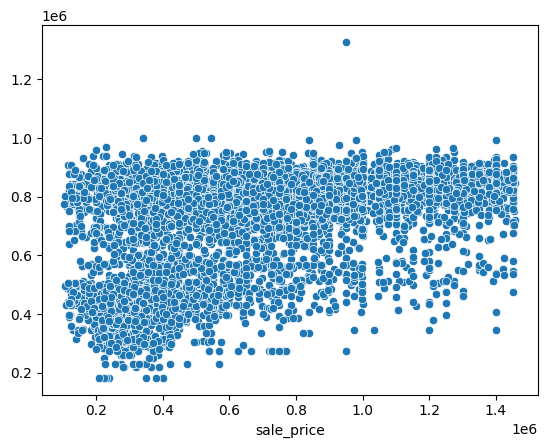

In [491]:
# If these values follow a line = good predictions
sns.scatterplot(x=y_test, y=predictions)

---

### Tester Row Values

|Step|Description|
|---|---|
|1| Data Cleaning |
|2| Transformation|
|3| ML Training & Metrics|
|4| <bold style="background:yellow;color:black;">Tester Row Values</bold>|
|5| Personal Analysis |
|6|GUI Application|
|7| Advanced Tasks|


Here, we'll create an example prediction dictionary row. I can refer to this when I create my GUI.

In [493]:
tester_row = {
    'is_high_cluster_unitstotal' : 1,
    'is_high_cluster_bldgarea': 0 ,
    'is_high_cluster_unitsres': 1,
    'unitstotal' : 8,
    'lotarea': 1900,
    'bldgclass_D4': 1,
    'unitsres': 2,
    'bldgarea': 1100,
    'bldgclass_C6': 0,
    'numfloors' : 4 
}

# Convert to pandas format
tester_row = pd.DataFrame([tester_row])

# Transform the columns again.
tester_row['unitstotal'] = np.log1p(tester_row[['unitstotal']])       # log transformation
tester_row['lotarea'] = np.log1p(tester_row[['lotarea']])             # log transformation
tester_row['unitsres'] = pt.fit_transform(tester_row[['unitsres']])   # yeo johnson
tester_row['bldgarea'] = pt.fit_transform(tester_row[['bldgarea']])   # yeo johnson

# Predict the result from the information above.
result = lm.predict(tester_row)[0]

# Print the result.
print(f"Predicted price for this home:")
print(f"$ {round(float(result), 2)}")



Predicted price for this home:
$ 463845.71


---

### Personal Analysis

<br>

|Step|Description|
|---|---|
|1| Data Cleaning |
|2| Transformation|
|3|ML Training & Metrics|
|4| Tester Row Values|
|5|<bold style="background:yellow;color:black;"> Personal Analysis </bold>|
|6|Model Application|
|7| Advanced Tasks|

<br>
<br>
<br>

In my personal analysis, I'll be performing the following process:

|Step|Description|
|---|---|
|1| Create a dataframe which can easily compare the `predicted_price` with the `sale_price`.|
|2| (I do research here)|
|3| Give some post-research observations.|

<br>
<br>
<br>


#### Creating a Dataframe with `predicted_price` and `error_margin`

Creating a dataframe that easily lets us check the results in one dataframe.

In [494]:
# Adding a column to the dataframe which predicted the price.
case_df = df
case_df['predicted_price'] = lm.predict(X).round(2)

# Creating an error margin column for the price for each row.
case_df["error_margin"] = abs(df["sale_price"] - df['predicted_price']).round(2)

case_df = case_df.sort_values("error_margin", ascending=False)

# Here, we can see some of the extreme cases with high error margins.
# NOTE: `error_margin` and `predicted_price` is at the end of the dataset

<h3>Post-Research Observations: </h3>

<div style="border: 3px dashed white; padding: 10px; box-sizing: border-box;">

<i>

I experimented by putting in a new model, `RandomForestRegressor` to see if it would give me improvements.
The results for `RandomForestRegressor` were notably better than `LinearRegression`. Here are the results:

</i>

<br>


|Random Forest Regressor Scatterplot (y-test, prediction)| Random Forest Regressor Performance Metrics|
|---|---|
|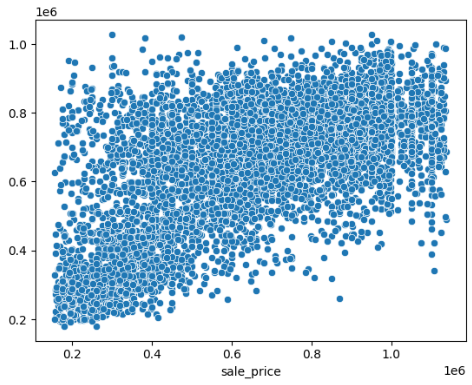|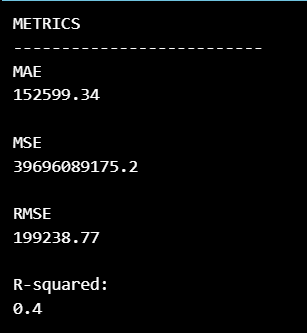|

I've done some research and some work related to WHY the performance metrics are so low with this particular dataset.

<br>
<i>
<strong style='color:orange ; background-color:black;'>
  TLDR: It's a dataset issue but also a model issue.
</strong></i>

### Reason 1</b>

<i>
<b>We're missing a key feature when it comes to NYC housing -- Maintenance contracts.</b>

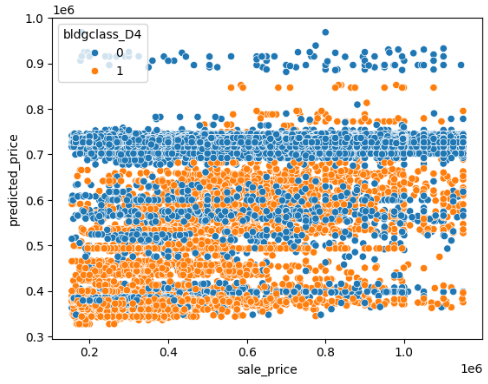

 Just like in Finland,
many homes are part of housing associations or come with a maintenance contract, which affect the price HEAVILY. These maintenance contracts 
correlate negatively with the sales price of the home/apartment (higher maintenance cost, lower home price).
 Look at the example below so you get an idea of what I mean. Assume that these two homes are the same just with different maintenance contracts/costs.
But say that they have different maintenance contracts.

</i>

<b>Example:</b>

|House|House Price| Maintenance Cost/month|
|---|---|---|
|1| 400,000| 1,200|
|2| 1,000,000| 300|

<br>
<i>

`bldgclass_D4` is an apartment co-op building class, which are homes that are notorious for having high variance in these maintenance fees. But these actually should all have this variance to a big degree.


### Reason 2

<b> Variance. </b> We're dealing with lot prices, not home prices. Commercial AND Residential. Some locations had 12 floors or 110 buildings in a single lot. And they weren't as uncommon as you'd think. 


### Conclusory Thoughts

Pretty frustrating dataset. I've spent around 40 hours on this one. I've tried a number of feature selection combinations, transformation methods, the works. 95% of these methods were fruitless. I spent the majority of my time reading articles for other people's approaches and concepts. The biggest improvement was separating binomial distributions and putting EACH AND EVERY possible X variable into the model. I opted not to show this in the final result, because it meant not showing how the feature selection process worked.

</i>

<b>Sources:</b> 

<i>
If you'd like to see how I made reached this conclusion:
</i>
<br>
<br>

|Number|Source|
|---|---|
|1|[A forum discussing the maintenance cost & resale price](https://streeteasy.com/talk/discussion/40799-should-i-be-scared-away-by-high-maintenance-fee)
|2|[A paper that not-so-briefly discusses the complexity of the problem](https://arxiv.org/pdf/2007.01171)
|3|https://datasciencedojo.com/blog/binomial-distribution-in-machine-learning/|

</div>


---

## Advanced Tasks

|Step|Description|
|---|---|
|1| Data Cleaning |
|2| Transformation|
|3|ML Training & Metrics|
|4| Tester Row Values|
|5| Personal Analysis|
|6| <bold style="background:yellow;color:black;">Advanced Tasks </bold>|

<br>
<br>

#### Advanced Task Contents


|Task|Description|
|---|---|
|1|<bold style="background:yellow;color:black;"> Experiment with polynomial and curve fitting features of `scikit-learn` with any dataset. Explain your findings in your Jupyter notebook, and analyze how useful they are.</bold>|
|2|Write down the multiple linear regression formula of your model by using the `intercept-` and `coeff–` variables in your model `–object`.|
|3|You can also consider using other regressors like `CatBoostRegressor` which allows you to use other types of data than numbers without transformations. Write down your experiences with this regressor.|

<br>
<br>

---

<br>

### Adv. Task 1 -- Polynomial, Curve-fitting feature experimentation

### _[Link to Notebook](ex1_adv1.ipynb)_

<br>

---

### Adv. Task 2 -- Print the Poly-Linear Regression



|Task|Description|
|---|---|
|1|Experiment with polynomial and curve fitting features of `scikit-learn` with any dataset. Explain your findings in your Jupyter notebook, and analyze how useful they are.|
|2|<bold style="background:yellow;color:black;"> Write down the multiple linear regression formula of your model by using the `intercept-` and `coeff–` variables in your model `–object`.</bold>|
|3|You can also consider using other regressors like `CatBoostRegressor` which allows you to use other types of data than numbers without transformations. Write down your experiences with this regressor.|

This shouldn't be terribly hard, especially since the intercept and coefficient are literally given as 
`intercept-` and `coeff-`. 

In [495]:
# The strategy will be to append a string with it's coefficients.
# IE: "Jere" + "my" = "Jeremy"

# First, we'll turn the coefficients into a list.
# This makes it easier to iterate over.
coefs_list = coefs.tolist()

# Second, we create a number translator for subscripts.
sub = str.maketrans("0123456789", "₀₁₂₃₄₅₆₇₈₉")

# Third, we create the string variable, startying with ` y =`
regression_string = "y = "

# Fourth, initiate a loop which will append to the string above.
# The `enumerate` in the loop will let me call the VALUE and the INDEX.
# The index will be used to generate new variable names.
# The value, `coef`, will let us call the weight.
# IE: WeightX₁ + WeightX₂ WeightX₃ 
for  index, coef in enumerate(coefs_list):
    index += 1
    index = str(index).translate(sub)
    coef = round(coef,2)

    regression_string += f"{coef}x{index} + " 

regression_string += str(intercept)
print(regression_string)


y = -149694.69x₁ + -96936.07x₂ + 640.44x₃ + -123979.02x₄ + 9808.04x₅ + -184592.55x₆ + 95824.98x₇ + 103980.32x₈ + -210481.82x₉ + 18519.11x₁₀ + 921773.7881121158


---

### Adv. Task 3 -- Using `CatBoostRegressor`

### _[Link to Notebook](ex1_adv3.ipynb)_